# Predicting Wild Blueberry Yield Using Regression Models

## Introduction:
This project focuses on predicting the yield of wild blueberries based on various factors using regression techniques. By analyzing relevant environmental and agricultural data, the goal is to build a reliable model that can forecast blueberry yield, aiding farmers in making informed decisions for better crop management and planning. The use of regression models will help in understanding the key variables that impact the yield, thus contributing to the efficiency of blueberry farming.




You can download the dataset for the Kaggle competition [Playground Series - Season 3, Episode 14](https://www.kaggle.com/competitions/playground-series-s3e14/data) from the official Kaggle competition page.


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import set_config
from sklearn.metrics import mean_squared_error

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
train.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [5]:
train.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64

In [6]:
test.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
dtype: int64

In [7]:
train.drop('id', axis=1, inplace=True)
train

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15284,12.5,0.25,0.25,0.38,0.50,77.4,46.8,64.7,55.8,27.0,45.8,16.0,0.26,0.556302,0.476308,40.546480,7667.83619
15285,12.5,0.25,0.25,0.25,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.354413,0.388145,29.467434,3680.56025
15286,25.0,0.50,0.25,0.38,0.75,77.4,46.8,64.7,55.8,27.0,45.8,34.0,0.56,0.422548,0.416786,32.299059,4696.44394
15287,25.0,0.50,0.25,0.63,0.63,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.542170,0.434133,36.674243,6772.93347


<Axes: >

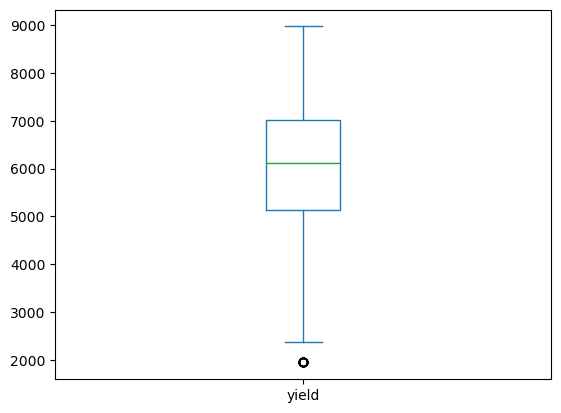

In [8]:
train['yield'].plot(kind = 'box')

In [9]:
train = train[['clonesize',
 'honeybee',
 'RainingDays',
 'AverageRainingDays',
 'fruitset',
 'fruitmass',
 'seeds',
 'yield'
]]

In [10]:
X = train.drop(['yield'], axis = 1)
y = train['yield']
X

,clonesize,honeybee,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,25.0,0.50,24.0,0.39,0.425011,0.417545,32.460887
1,25.0,0.50,24.0,0.39,0.444908,0.422051,33.858317
2,12.5,0.25,24.0,0.39,0.552927,0.470853,38.341781
3,12.5,0.25,24.0,0.39,0.565976,0.478137,39.467561
4,25.0,0.50,24.0,0.39,0.579677,0.494165,40.484512
...,...,...,...,...,...,...,...
15284,12.5,0.25,16.0,0.26,0.556302,0.476308,40.546480
15285,12.5,0.25,34.0,0.56,0.354413,0.388145,29.467434
15286,25.0,0.50,34.0,0.56,0.422548,0.416786,32.299059
15287,25.0,0.50,24.0,0.39,0.542170,0.434133,36.674243


In [11]:
X_train, X_test, y_train , y_test = train_test_split(X, y,
                                     test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [13]:
def display_scores(scores):
    print("Scores: ", scores)
    print("Mean: ", scores.mean())
    print("Standard deviation: ", scores.std())

In [14]:
def gs(model, pram_grid):
    # Create GridSearchCV object
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error')

    # Fit GridSearchCV object to data
    grid_search.fit(X, y)

    # Access best parameters and best score after fitting
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)

In [15]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [16]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
scores = cross_val_score(lm, X_train_scaled, y_train, cv=10,scoring='neg_mean_absolute_error')
display_scores(scores)

Scores:  [-397.34049373 -376.21880843 -384.01636319 -350.24169469 -372.79194865
 -382.54080232 -357.48378018 -366.98522026 -371.69536885 -370.35665713]
Mean:  -372.9671137436577
Standard deviation:  12.72320886172401


In [17]:
from sklearn.linear_model import Ridge
model = Ridge()
param_grid = {'alpha': [0.01,0.1, 1.0, 10.0]}
gs(model, param_grid)

Best Parameters: {'alpha': 0.01}
Best Score: -372.7240233045815


In [18]:
from sklearn.linear_model import Ridge
model = Ridge(alpha = 0.01)
scores = cross_val_score(model, X_train_scaled, y_train, cv=10,scoring='neg_mean_absolute_error')
display_scores(scores)

Scores:  [-397.34051387 -376.21888178 -384.01638601 -350.24181021 -372.79179269
 -382.54092009 -357.48388958 -366.98535273 -371.69558072 -370.35670952]
Mean:  -372.96718372023787
Standard deviation:  12.723182285482613


In [19]:
from sklearn.linear_model import Lasso
lasso_model = Lasso()
param_grid = {'alpha':  [0.01,0.1, 1.0, 10.0]}
gs(model, param_grid)

Best Parameters: {'alpha': 0.01}
Best Score: -372.7240233045815


In [20]:
from sklearn.linear_model import Lasso
model = Lasso(alpha = 0.01)
scores = cross_val_score(model, X_train_scaled, y_train, cv=10,scoring='neg_mean_absolute_error')
display_scores(scores)

Scores:  [-397.33724287 -376.22241059 -384.0026994  -350.24129366 -372.78136562
 -382.54849667 -357.48585205 -366.98422906 -371.70606165 -370.35848115]
Mean:  -372.96681327280646
Standard deviation:  12.721808794620575


In [33]:
import xgboost as xgb
model = xgb.XGBRegressor(learning_rate = 0.1, max_depth = 5, n_estimators = 100)
scores = cross_val_score(model, X_train_scaled, y_train, cv=10,scoring='neg_mean_absolute_error')
display_scores(scores)

Scores:  [-379.02389399 -363.65530793 -366.66015443 -337.02683292 -358.19656904
 -363.49087847 -339.75157197 -343.49240084 -354.30514167 -358.8905593 ]
Mean:  -356.44933105653297
Standard deviation:  12.461628768743209


In [35]:
steps=[('scaler', StandardScaler()), ('xg',xgb.XGBRegressor(learning_rate = 0.1, max_depth = 5, n_estimators = 100))]
pipe = Pipeline(steps=steps)

In [39]:
pipe.fit(X_train, y_train)
y_predict = pipe.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
print("mse = ",mse)
rmse = np.sqrt(mse)
print("rmse = ",rmse)
r2 = r2_score(y_test,y_predict)
print("r2 = ",r2)

mse =  319591.2786052657
rmse =  565.3240474323251
r2 =  0.8182008183609982


In [41]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xg',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [43]:
id = test['id']

In [45]:
test = test[['clonesize',
 'honeybee',
 'RainingDays',
 'AverageRainingDays',
 'fruitset',
 'fruitmass',
 'seeds']]


In [51]:
y_predict = pipe.predict(test)

In [53]:
results = pd.DataFrame(y_predict)

In [55]:
results = pd.DataFrame({'id': id, 'y_pred': y_predict})

In [57]:
results = pd.DataFrame({'yield': y_predict}, index=id)
results.index.name = 'id'

In [59]:
results.to_csv('sub.csv')

### Conclusion

In this regression task, **XGBoost** outperformed other models, achieving the lowest **Mean Absolute Error (MAE)** of -356.45. The **R2 score** of 0.82 indicates that the model explains 82% of the variance. Additionally, the **Kaggle submission score** was **357.65731**, reflecting the model's performance in the competition. The **RMSE** of 565.32 shows the average prediction error, suggesting good predictive accuracy with room for further improvement.
